In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression, SGDRegressor
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error)

import xgboost as xgb
import shap

# save/load models
import joblib

# For the permutation importance implementation
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array

# Load the pre-processed data
df_with_descriptors = pd.read_pickle('processed_data.pkl')

In [60]:
df_with_descriptors.shape

(7973, 20)

In [61]:
RANDOM_SEED = 101
np.random.seed(RANDOM_SEED)

Defining Feature and Target Columns

In [62]:
#Comment out non-utilized features
TARGET_COLS = 'Tc'
FEATURES_COLS = (
    #'FFV',
    'Density',
    'Rg',
    #'Tg', 
    'MW',
    'LogP',
    'TPSA',
    'HBD',
    'HBA',
    'RotBonds',
    'NumHeavyAtoms',
    'NumHeteroatoms',
    'RingCount',
    'NumAromaticRings',
    'FractionCSP3',
    # 'canonical_smiles', # Note: This is a string representation, often needs further featurization (e.g., fingerprints)
    # 'molecule'          # Note: This is an RDKit Mol object, needs conversion to numerical features
)

print(f"Target Columns: {TARGET_COLS}")
print(f"Feature Columns: {FEATURES_COLS}")


Target Columns: Tc
Feature Columns: ('Density', 'Rg', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'NumHeavyAtoms', 'NumHeteroatoms', 'RingCount', 'NumAromaticRings', 'FractionCSP3')


Further Data Processing: duplicate removal, removing rows with NaNs -> Ensures remaining rows have complete data

In [63]:
df_with_descriptors = df_with_descriptors.drop_duplicates()
# Drop rows where 'Tc', 'LogP', 'RotBonds', or 'NumHeavyAtoms' have NaN values
df_with_descriptors = df_with_descriptors.dropna(subset=['Tc','LogP','Rg','RotBonds','Density','NumHeavyAtoms','MW','TPSA','HBD','HBA','NumHeteroatoms','RingCount','NumAromaticRings','FractionCSP3'])
print(f"Number of rows after removing NaN values in specified columns: {df_with_descriptors.shape[0]}")

Number of rows after removing NaN values in specified columns: 531


Target Feature Distribution

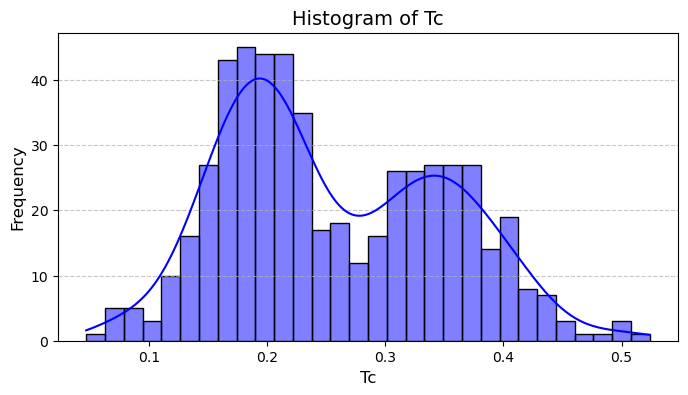

In [64]:
# Plot histogram of the target
plt.figure(figsize=(8, 4))
sns.histplot(df_with_descriptors[TARGET_COLS], kde=True, bins=30, color='blue')

# Add labels and title
plt.xlabel(f"{TARGET_COLS}", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title(f"Histogram of {TARGET_COLS}", fontsize=14)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Stratified Data Splitting: Assign High-performing vs Low-performing polymer classes

In [65]:
TARGET_BINARY = "target_binned"  # name of the new binary target column
THRESHOLD = 0.3  # fixed numeric threshold

# Create the binary target on the already cleaned df_with_descriptors for stratification
df_with_descriptors[TARGET_BINARY] = (df_with_descriptors[TARGET_COLS] > THRESHOLD).astype(int)

In [66]:
# Verify we have two classes
print("Class distribution for stratification:")
print(df_with_descriptors[TARGET_BINARY].value_counts())

Class distribution for stratification:
target_binned
0    341
1    190
Name: count, dtype: int64


In [67]:
# Perform train_test_split on the cleaned df_with_descriptors
df_train, df_test = train_test_split(
    df_with_descriptors, 
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_with_descriptors[TARGET_BINARY] # Stratify using the binary target from cleaned df
)

print(f"df_train shape: {df_train.shape}")
print(f"df_test shape: {df_test.shape}")

df_train shape: (424, 21)
df_test shape: (107, 21)


Find Low-Variance Features

In [68]:
variances = df_train[list(FEATURES_COLS)].var() #FEATURES_COLS is a tuple

# We use a small tolerance for floating-point comparison
redundant_features = variances[variances < 1e-9].index.tolist()

print(f"Features with zero or near-zero variance: {redundant_features}")

print(f"Number of features before: {len(FEATURES_COLS)}")
FEATURES_COLS = [feature for feature in FEATURES_COLS if not feature in redundant_features]
print(f"Number of features after: {len(FEATURES_COLS)}")

Features with zero or near-zero variance: []
Number of features before: 13
Number of features after: 13


Linear Model

In [70]:
# Initialize the Linear Regression model
linear_regressor = LinearRegression()

# Train the model on the training data
linear_regressor.fit(df_train[FEATURES_COLS], df_train[TARGET_COLS])

# Evaluate the model on the training and test sets
def linear_regression_metrics(Model, X, y_true):
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = Model.predict(X)

    mae = mean_absolute_error(y_true,y_predicted)
    mse = mean_squared_error(y_true,y_predicted)
    maximum_error = max_error(y_true,y_predicted)
    mape = mean_absolute_percentage_error(y_true,y_predicted)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

linear_regression_model =[('model',linear_regressor)]
linear_regression_result_test={}
linear_regression_result_train ={}

for model_name, model in linear_regression_model:
    print(f"Calculating metrics for {model_name}")
    linear_regression_result_test[model_name]= linear_regression_metrics(model,df_test[FEATURES_COLS], df_test[TARGET_COLS])
    linear_regression_result_train[model_name] = linear_regression_metrics(model,df_train[FEATURES_COLS], df_train[TARGET_COLS])

# Print the results
print("Linear Regression Results - Train Set:", linear_regression_result_train)
print("Linear Regression Results - Test Set:", linear_regression_result_test)

Calculating metrics for model
Linear Regression Results - Train Set: {'model': {'mae': 0.0332675480993984, 'mse': 0.0020698293048780846, 'max_error': 0.2516790081426114, 'mape': 0.14411787139888768}}
Linear Regression Results - Test Set: {'model': {'mae': 0.040446305596420554, 'mse': 0.0031824684068649826, 'max_error': 0.2815771667983439, 'mape': 0.1751953446713661}}
